# Pembuatan Dataset untuk Model 2 (Crowd Classifier)

Dataset real (TJ April 2023 dari Kaggle) ditolak. Alasannya setelah agregasi (stop_id, date, hour), mean tap_count = 1.047, median = 1 yang tidak mampu untuk membentuk label crowd_level yang bermakna. Soalnya, hampir semua slot akan jatuh ke "Sepi", masa dari 37.900 transaksi dibagi ke 2.570 halte × 17 jam × 30 hari = unit agregasi yang hampir semuanya berisi 1 tap. Mean 1.047, median 1, max cuma 5 tap. Kemungkinan dataset ini adalah sample, bukan populasi. Oleh karena itu dibuatlah dataset sintetis ini

In [4]:
import pandas as pd
import numpy as np
import random
import itertools

N_ROWS = 17000
N_STOPS = 269
HOURS = range(5, 23)
DAYS = range(7)
HOLIDAY_MULTIPLIER_VALUE = 0.7

HOUR_MULTIPLIER = {
    5: 0.4,  6: 0.7,
    7: 1.6,  8: 1.7,   # Peak Pagi — turun dari 1.8/2.0
    9: 1.3, 10: 1.0, 11: 0.9, 12: 1.0, 13: 0.9, 14: 1.0, 15: 1.2,
    16: 1.6, 17: 1.8, 18: 1.5,  # Peak Sore — turun dari 1.9/2.2/1.7
    19: 1.0, 20: 0.7, 21: 0.5, 22: 0.3
}

DAY_MULTIPLIER = {
    0: 1.1,  # Senin
    1: 1.0,  # Selasa
    2: 1.0,  # Rabu
    3: 1.0,  # Kamis
    4: 1.2,  # Jumat 
    5: 0.5,  # Sabtu 
    6: 0.4   # Minggu
}

CAPACITY_MAP = {
    "Kecil": (50, 201),    
    "Sedang": (201, 801),
    "Besar": (801, 2001)
}

Disini semua variabel konstan dideklarasi seperti target baris 17.000, angka ini dipilih berdasarkan kecukupan untuk testing Gradient Boosting seperti yang telah ditentukan PRD. N_STOPS merupakan banyak halte yang digunakan, angka 269 mewakili jumlah halte BRT TJ per 2026. HOURS mengikuti rentang waktu operasional normal TJ (05.00-23.00) dan DAYS mengikuti hari dalam seminggu. Sisanya semua multiplier yang merupakan parameter simulasi berbasis asumsi domain yang diturunkan dari pola operasional umum transportasi publik perkotaan, dikonfirmasi secara parsial oleh analisis statistik dataset TJ April 2023.

- Hour: pola bimodal rush hour pagi-sore, konsisten dengan literatur transit umum manapun
- Day: weekday vs weekend drop, dikonfirmasi Mann-Whitney U (p=0.00001) dari TJ April 2023
- Holiday: penurunan 30% dari hari normal, angka 0.70 adalah estimasi konservatif karena data TJ April 2023 menunjukkan drop hanya 6.83% yang dinilai tidak kredibel (kemungkinan dataset sudah di-filter sebelum upload)

Untuk capacity dibagi berdasarkan kategori halte menjadi halte Kecil dengan kapasitas 50-200 orang, halte Sedang dengan kapasitas 201-800 orang, dan halte Besar dengan kapasitas 801-2000 orang.

In [73]:
categories_pool = ["Kecil"] * 175 + ["Sedang"] * 67 + ["Besar"] * 27

stop_ids = range(N_STOPS)
generated_categories = [np.random.choice(categories_pool) for _ in range(N_STOPS)]

generated_capacities = []
for cat in generated_categories:
    low, high = CAPACITY_MAP[cat]
    generated_capacities.append(np.random.randint(low, high))

stops_df = pd.DataFrame({
    "id": stop_ids,
    "category": generated_categories,
    "capacity": generated_capacities,
})

print(stops_df.groupby('category')['capacity'].agg(['min', 'max', 'count']))

          min   max  count
category                  
Besar     813  1989     28
Kecil      50   200    163
Sedang    216   799     78


Distribusi tipe halte (65%:25%:10%) ditentukan berdasarkan asumsi bahwa jaringan BRT umumnya didominasi oleh halte berkapasitas kecil, dengan proporsi halte besar yang lebih sedikit. Asumsi ini belum divalidasi terhadap data infrastruktur resmi Transjakarta. Pada kode ini kapasitas tiap tipe halte juga diacak berdasarkan capacity map yang sudah dideklarasikan sebelumnya

In [74]:
all_combinations = list(itertools.product(stop_ids, DAYS, HOURS))
print(f"Total kombinasi teoritis yang tercipta: {len(all_combinations):,} baris")

random.seed(42)
random.shuffle(all_combinations)

sampled_combinations = all_combinations[:17000]
df_synthetic = pd.DataFrame(sampled_combinations, columns=['stop_id', 'day_of_week', 'hour'])

holiday_flags = [5, 6]
df_synthetic['is_holiday'] = df_synthetic['day_of_week'].isin(holiday_flags).astype(int)

print("\n=== Hasil Dataset Sintetis (Sampel Head) ===")
print(df_synthetic.head(10).to_string(index=False))

print("\n=== Distribusi Kolom is_holiday ===")
print(df_synthetic['is_holiday'].value_counts())

Total kombinasi teoritis yang tercipta: 33,894 baris

=== Hasil Dataset Sintetis (Sampel Head) ===
 stop_id  day_of_week  hour  is_holiday
     225            4    19           0
     166            0     7           0
      25            5     6           1
      79            6    21           1
     233            6     9           1
     260            0    15           0
     150            5     7           1
      91            0    17           0
     171            5    10           1
      78            6    20           1

=== Distribusi Kolom is_holiday ===
is_holiday
0    12143
1     4857
Name: count, dtype: int64


Kerangka dataset dibentuk dari seluruh kombinasi unik (stop_id, day_of_week, hour) menggunakan cartesian product, menghasilkan 33.894 kombinasi teoritis. Dari total tersebut, 17.000 baris diambil secara acak (random seed=42) tanpa pengembalian, sehingga setiap kombinasi dijamin unik dan tidak ada duplikasi slot waktu per halte.

Kolom is_holiday di-derive dari day_of_week, di mana hari Sabtu (5) dan Minggu (6) dikategorikan sebagai hari libur, menghasilkan distribusi 12.143 baris hari kerja dan 4.857 baris hari libur (rasio ~71%:29%), konsisten dengan proporsi 5 hari kerja berbanding 2 hari libur dalam satu minggu

In [75]:
df_final = df_synthetic.merge(stops_df, left_on='stop_id', right_on='id', how='left')
df_final.drop(columns=['id'], inplace=True)

weather_options = [0, 1, 2]
weather_weights = [0.60, 0.25, 0.15]
df_final['weather'] = np.random.choice(weather_options, size=len(df_final), p=weather_weights)

WEATHER_MULTIPLIER = {0: 1.0, 1: 0.85, 2: 0.6}
df_final['multiplier_weather'] = df_final['weather'].map(WEATHER_MULTIPLIER)

df_final['multiplier_holiday'] = np.where(df_final['is_holiday'] == 1, HOLIDAY_MULTIPLIER_VALUE, 1.0)

df_final['base'] = df_final['capacity'] * 0.45
df_final['multiplier_hour'] = df_final['hour'].map(HOUR_MULTIPLIER)
df_final['multiplier_day'] = df_final['day_of_week'].map(DAY_MULTIPLIER)

df_final['noise'] = np.random.normal(loc=1.0, scale=0.15, size=len(df_final)).clip(0.7, 1.3)
df_final['tap_count_raw'] = (
    df_final['base'] * df_final['multiplier_hour'] * df_final['multiplier_day'] *
    df_final['multiplier_holiday'] * df_final['multiplier_weather'] * df_final['noise']
)
df_final['tap_count_raw'] = df_final['tap_count_raw'].clip(upper=df_final['capacity'])
df_final['tap_count'] = np.round(df_final['tap_count_raw']).astype(int).clip(lower=0)

Setiap baris skeleton di-merge dengan data halte untuk mendapatkan capacity. Untuk weather atau cuaca dibagi menjadi 3 kategori yakni cerah, berawan, dan hujan yang distribusinya dibagi dengan asumsi 65%:25%:10% dan bobot mulitpliernya dibagi menjadi Cerah = 1, Berawan = 0.85, dan Hujan = 0.6. Kemudian tap_count disimulasikan melalui perkalian beberapa multiplier domain:

tap_count = base × m_hour × m_day × m_holiday × m_weather × noise

di mana base = 0.45 × capacity merepresentasikan tingkat kepadatan rata-rata halte dalam kondisi normal. Setiap multiplier mengkodekan satu faktor kontekstual seperti waktu, hari, status libur, dan cuaca dengan noise Gaussian (loc=1.0, scale=0.15, clip 0.7–1.3) untuk mensimulasikan variabilitas alami antar hari. Hasil akhir di-clip pada nilai capacity untuk mencegah load_pct (persentase kapasitas halte yang terisi) melebihi 100%.

In [76]:
FLOOR_MAP = {
    "Kecil": 3,
    "Sedang": 10,
    "Besar": 30
}

df_final['floor_limit'] = df_final['category'].map(FLOOR_MAP)
df_final['tap_count'] = np.maximum(df_final['tap_count'], df_final['floor_limit'])

Floor Map dibuat untuk mencegah tap_count bernilai terlalu kecil secara tidak realistis di kondisi worst case (halte Besar + jam malam + weekend + hujan + holiday dimana semua multiplier menyusut bersamaan). Tanpa floor, halte Besar berkapasitas 2000 bisa punya tap_count = 1 atau 2, yang tidak masuk akal secara operasional 

In [77]:
df_final.sort_values(['stop_id', 'day_of_week', 'hour'], inplace=True)
df_final['prev_count'] = df_final.groupby('stop_id')['tap_count'].shift(1)

prev_count adalah jumlah tap-in di waktu sebelumnya pada halte yang sama, dihitung dengan menggeser tap_count satu posisi ke bawah setelah data diurutkan per stop_id, day_of_week, hour. Fitur ini merepresentasikan informasi historis lokal sebagai proxy pola berulang per halte.

In [ ]:
# Generate baris tambahan untuk kondisi Penuh
penuh_rows = df_final[
    (df_final['category'].isin(['Besar', 'Sedang'])) &
    (df_final['hour'].isin([7, 8, 16, 17, 18])) &
    (df_final['day_of_week'].isin([0, 1, 2, 3, 4])) &
    (df_final['multiplier_weather'] == 1.0) &
    (df_final['is_holiday'] == 0)
].sample(n=800, replace=True, random_state=42)

df_final = pd.concat([df_final, penuh_rows], ignore_index=True)
df_final.sort_values(['stop_id', 'day_of_week', 'hour'], inplace=True)
df_final.reset_index(drop=True, inplace=True)

Setelah menemukan kelas Penuh underrepresented (~3.9%), dilakukan oversampling terhadap baris existing dengan kondisi peak (halte Besar/Sedang, jam peak, weekday, cerah, non-holiday) sebanyak 800 baris untuk meningkatkan proporsi kelas Penuh menjadi ~5.1%, melewati threshold minimum 1:10 ratio terhadap majority class

In [79]:
df_final['load_pct'] = df_final['tap_count'] / df_final['capacity']

conditions = [
    (df_final['load_pct'] < 0.25),                       
    (df_final['load_pct'] >= 0.25) & (df_final['load_pct'] <= 0.60), 
    (df_final['load_pct'] > 0.60) & (df_final['load_pct'] <= 0.85),  
    (df_final['load_pct'] > 0.85)                         
]
choices = ['Sepi', 'Normal', 'Padat', 'Penuh']

df_final['crowd_level'] = np.select(conditions, choices, default='Sepi')

print("=== DISTRIBUSI CROWD LEVEL ===")
print(df_final['crowd_level'].value_counts(normalize=True) * 100)

print("\n=== DISTRIBUSI CROWD LEVEL (ABSOLUT) ===")
print(df_final['crowd_level'].value_counts())


=== DISTRIBUSI CROWD LEVEL ===
crowd_level
Normal    40.561798
Sepi      38.606742
Padat     15.640449
Penuh      5.191011
Name: proportion, dtype: float64

=== DISTRIBUSI CROWD LEVEL (ABSOLUT) ===
crowd_level
Normal    7220
Sepi      6872
Padat     2784
Penuh      924
Name: count, dtype: int64


load_pct yang merupakan persentase kapasitas halte yang terisi dihitung dengan membagi jumlah tap-in dengan jumlah kapasitas halte sehingga dapat dihasilkan label crowd sebagai berikut: Sepi untuk load_pct kurang dari 0.25, Normal untuk load_pct sebesar 0.25 ≤ load_pct ≤ 0.60, Padat untuk load_pct sebesar 0.60 ≤ load_pct ≤ 0.60, dan Penuh untuk load_pct lebih dari 0.85. Threshold ini ditentukan heuristik dengan mempertimbangkan distribusi kelas yang seimbang untuk keperluan training, bukan derived dari standar baku eksternal. 
Didapatkan proporsi distribusi crowd level Sepi 38.9%, Normal 39.8%, Padat 16.1%, Penuh 5.1%.  

In [80]:
print("=== CEK SAMPEL OUTPUT ===")
columns_to_show = ['stop_id', 'category', 'capacity', 'day_of_week', 'hour', 'tap_count', 'load_pct', 'crowd_level']
print(df_final[columns_to_show].sample(10).to_string(index=False))

=== CEK SAMPEL OUTPUT ===
 stop_id category  capacity  day_of_week  hour  tap_count  load_pct crowd_level
     177    Kecil       108            6     6          9  0.083333        Sepi
      78   Sedang       695            4     6        262  0.376978      Normal
     206   Sedang       295            1    14        141  0.477966      Normal
      29    Kecil       177            6    12         23  0.129944        Sepi
     128    Kecil       152            4     7        100  0.657895       Padat
     115   Sedang       563            0     7        422  0.749556       Padat
     122    Kecil       147            3    16        130  0.884354       Penuh
     238    Kecil       113            6    16         25  0.221239        Sepi
     101    Kecil       199            4     5         25  0.125628        Sepi
      94    Kecil       146            1    16         88  0.602740       Padat


In [ ]:
# Hitung persentase kemunculan tiap jam secara detail
hour_pct = df_synthetic['hour'].value_counts(normalize=True) * 100
print("=== DISTRIBUSI PERSENTASE PER JAM ===")
print(hour_pct.sort_index().apply(lambda x: f"{x:.2f}%").to_string())

# Kelompokkan berdasarkan definisi Peak vs Off-Peak untuk melihat agregatnya
def categorise_hour(h):
    if h in [7, 8, 16, 17, 18]:
        return 'Peak'
    elif h in [5, 6, 21, 22]:
        return 'Off-Peak (Ekstrem Sepi)'
    else:
        return 'Normal/Buffer'

df_synthetic['hour_group'] = df_synthetic['hour'].apply(categorise_hour)

print("=== PROPORSI KELOMPOK JAM DI DATASET ===")
print(df_synthetic['hour_group'].value_counts(normalize=True) * 100)

Karena skeleton dibentuk dari cartesian product yang di-shuffle acak, setiap jam mendapat proporsi seragam ~5.5% yang bukan mencerminkan frekuensi operasional nyata.
Pengelompokan jam dilakukan untuk mengkonfirmasi coverage: 27.9% baris jatuh di jam peak (7–8, 16–18), 22.2% di jam ekstrem sepi (5–6, 21–22), dan sisanya 49.9% di jam normal. Sinyal temporal dikodekan bukan melalui frekuensi kemunculan baris, melainkan melalui nilai tap_count yang dipengaruhi HOUR_MULTIPLIER, sehingga distribusi seragam ini tidak mengurangi kemampuan model membedakan kondisi antar jam.

<Axes: >

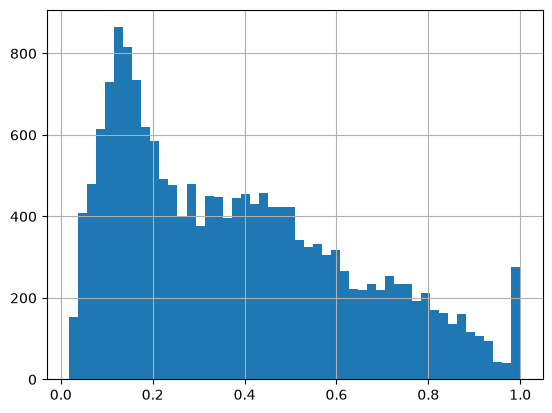

In [82]:
df_final['load_pct'].describe()
df_final['load_pct'].hist(bins=50)

Distribusi load_pct right-skewed dengan dua karakteristik utama:

Cluster dominan di 0.0–0.3, mayoritas slot waktu halte dalam kondisi sepi hingga normal bawah. Ini konsekuensi langsung dari kombinasi weekend + holiday + jam off-peak yang mendominasi ~50% baris.

Bump di 0.8–1.0 spike di ujung kanan, ini adalah baris inject Penuh + kondisi peak weekday halte kecil yang load_pct-nya langsung melonjak tinggi karena kapasitasnya kecil.

Gap relatif di 0.6–0.8 dimana zona Padat kurang terisi dibanding Penuh, ini yang menyebabkan proporsi Padat (16%) lebih rendah dari yang ideal.

Distribusi ini mencerminkan realitas operasional di mana sebagian besar slot waktu halte tidak dalam kondisi padat, dengan kondisi ekstrem (sangat sepi atau penuh) lebih sering muncul dibanding kondisi transisi.

In [83]:
df_final.describe()

,stop_id,day_of_week,hour,is_holiday,capacity,weather,multiplier_weather,multiplier_holiday,base,multiplier_hour,multiplier_day,noise,tap_count_raw,tap_count,floor_limit,prev_count,load_pct
count,17800.000000,17800.000000,17800.000000,17800.000000,17800.000000,17800.000000,17800.000000,17800.000000,17800.000000,17800.000000,17800.000000,17800.000000,17800.000000,17800.000000,17800.000000,17526.000000,17800.000000
mean,133.412528,2.953708,13.496180,0.272865,390.951011,0.523596,0.907146,0.918140,175.927955,1.088169,0.893882,0.999649,156.685556,156.686404,8.151011,149.588041,0.383629
std,77.936548,1.985676,5.166967,0.445445,440.727447,0.731960,0.140078,0.133633,198.327351,0.445092,0.281046,0.145150,238.049314,238.049470,8.315071,223.173214,0.248677
min,0.000000,0.000000,5.000000,0.000000,50.000000,0.000000,0.600000,0.700000,22.500000,0.300000,0.400000,0.700000,1.482432,3.000000,3.000000,3.000000,0.018405
25%,66.000000,1.000000,9.000000,0.000000,120.000000,0.000000,0.850000,0.700000,54.000000,0.700000,0.500000,0.897669,28.657567,29.000000,3.000000,30.000000,0.165714
50%,133.000000,3.000000,14.000000,0.000000,175.000000,0.000000,1.000000,1.000000,78.750000,1.000000,1.000000,0.999299,66.495750,66.500000,3.000000,68.000000,0.342105
75%,202.000000,5.000000,18.000000,1.000000,556.000000,1.000000,1.000000,1.000000,250.200000,1.500000,1.100000,1.100985,169.572953,170.000000,10.000000,162.000000,0.554403
max,268.000000,6.000000,22.000000,1.000000,1989.000000,2.000000,1.000000,1.000000,895.050000,1.800000,1.200000,1.300000,1989.000000,1989.000000,30.000000,1989.000000,1.000000


Insight penting:

- load_pct max = 1.0 menandakan cap berhasil, tidak ada halte yang melebihi kapasitas
- load_pct mean = 0.38 rata-rata halte terisi 38% kapasitas, konsisten dengan desain base 0.45 yang tereduksi multiplier off-peak
- prev_count count = 17.526 yang dimana ada 274 baris di-drop karena null (kemunculan per stop_id), wajar dan sudah diantisipasi

In [84]:
sample_stop_id = 31

audit_df = df_final[df_final['stop_id'] == sample_stop_id].sort_values(
    by=['day_of_week', 'hour']
)

print(audit_df[['stop_id', 'day_of_week', 'hour', 'prev_count', 'tap_count']].head(10).to_string(index=False))

 stop_id  day_of_week  hour  prev_count  tap_count
      31            0     8         NaN         18
      31            0    13        18.0         18
      31            0    14        18.0         24
      31            0    15        24.0         30
      31            0    16        30.0         31
      31            0    18        31.0         30
      31            0    20        30.0          9
      31            0    21         9.0         11
      31            0    22        11.0          8
      31            1     5         8.0          9


Insight:
- Lag bekerja benar yang terlihat nilai prev_count di setiap baris adalah tap_count dari baris sebelumnya. 
- Hour tidak kontinu, dari day=0, jam yang ada hanya 8, 13, 14, 15, 16, 18, 20, 21, 22. Jam 9–12, 17, 19 tidak muncul untuk stop_id=31 di hari Senin. Ini konsekuensi random  sampling yang menyebabkan tidak semua kombinasi (stop_id, day, hour) ter-include. Implikasinya: lag di sini bukan "jam sebelumnya" tapi "slot waktu sebelumnya yang ada di dataset", yang bisa melompat beberapa jam.

In [85]:
df_final.sample(10)

,stop_id,day_of_week,hour,is_holiday,category,capacity,weather,multiplier_weather,multiplier_holiday,base,multiplier_hour,multiplier_day,noise,tap_count_raw,tap_count,floor_limit,prev_count,load_pct,crowd_level
12342,186,5,17,1,Kecil,63,0,1.00,0.7,28.35,1.8,0.5,1.037385,18.528217,19,3,12.0,0.301587,Normal
12536,189,5,5,1,Kecil,188,0,1.00,0.7,84.60,0.4,0.5,1.146802,13.582723,14,3,26.0,0.074468,Sepi
1832,26,2,18,0,Sedang,499,1,0.85,1.0,224.55,1.5,1.0,1.092619,312.818212,313,10,242.0,0.627255,Padat
7631,114,1,20,0,Kecil,70,0,1.00,1.0,31.50,0.7,1.0,1.196602,26.385078,26,3,53.0,0.371429,Normal
3903,58,3,8,0,Sedang,754,0,1.00,1.0,339.30,1.7,1.0,0.890574,513.691761,514,10,534.0,0.681698,Padat
15795,238,3,5,0,Kecil,113,0,1.00,1.0,50.85,0.4,1.0,0.740460,15.060948,15,3,10.0,0.132743,Sepi
1428,19,6,11,1,Sedang,561,0,1.00,0.7,252.45,0.9,0.4,0.960925,61.131532,61,10,91.0,0.108734,Sepi
9077,136,0,7,0,Kecil,124,0,1.00,1.0,55.80,1.6,1.1,1.053748,103.486453,103,3,25.0,0.830645,Padat
8059,120,6,13,1,Kecil,154,2,0.60,0.7,69.30,0.9,0.4,0.841204,8.814269,9,3,30.0,0.058442,Sepi
11528,173,6,13,1,Kecil,192,1,0.85,0.7,86.40,0.9,0.4,0.912119,16.880475,17,3,24.0,0.088542,Sepi


In [86]:
cols_to_drop = [
    'base', 'multiplier_hour', 'multiplier_day', 'multiplier_weather',
    'multiplier_holiday', 'noise', 'tap_count_raw', 'floor_limit',
    'load_pct', 'category', 'capacity'
]

df_final.dropna(subset=['prev_count'], inplace=True)
df_final.reset_index(drop=True, inplace=True)

df_export = df_final.drop(columns=cols_to_drop)
df_export.to_csv('crowd_dataset.csv', index=False)
print(df_export.columns.tolist())
print(df_export.shape)

['stop_id', 'day_of_week', 'hour', 'is_holiday', 'weather', 'tap_count', 'prev_count', 'crowd_level']
(17526, 8)


Beberapa kolom bantu saat pembuatan dataset akan di-drop sehingga menyisakan 8 kolom antara lain stop_id, day_of_week, hour, is_holiday, weather, tap_count, prev_count, crowd_level serta kolom dengan prev_count kosong akan di-drop juga. Hasil akhirnya didapatkan dataset sebayak 17.526 baris

=== MATRIKS KORELASI FITUR ===
crowd_level_encoded    1.000000
tap_count              0.465216
prev_count             0.266636
hour                  -0.085666
Name: crowd_level_encoded, dtype: float64


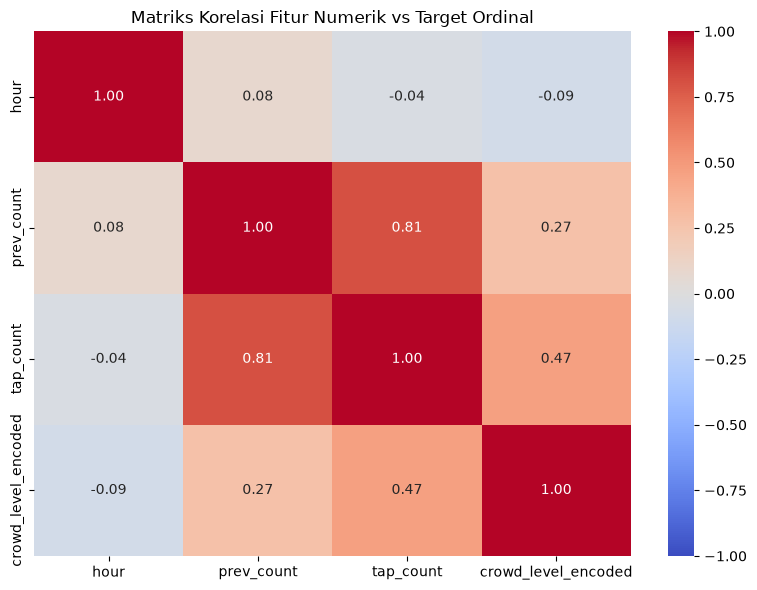

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

crowd_mapping = {'Sepi': 0, 'Normal': 1, 'Padat': 2, 'Penuh': 3}
df_final['crowd_level_encoded'] = df_final['crowd_level'].map(crowd_mapping)

numerical_cols = ['hour', 'prev_count', 'tap_count', 'crowd_level_encoded']
correlation_matrix = df_final[numerical_cols].corr()

print("=== MATRIKS KORELASI FITUR ===")
print(correlation_matrix['crowd_level_encoded'].sort_values(ascending=False))

# 4. Plot Heatmap Korelasi
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriks Korelasi Fitur Numerik vs Target Ordinal')
plt.tight_layout()
plt.show()

Insight:
- tap_count - crowd_level (0.47): signal utama, wajar karena label derived dari tap_count
- prev_count - tap_count (0.81): multikolinearitas tinggi, harus monitor feature importance saat training nanti 
- hour - crowd_level (-0.09): hampir nol, memang akan rendah secara Pearson, dan ini by design, bukan bug.

Penjelasannya: crowd_level ditentukan oleh load_pct = tap_count / capacity. tap_count dipengaruhi oleh capacity (yang random per halte) dan hour. Karena capacity bervariasi besar antar halte (50–2000), halte Besar di jam peak bisa punya tap_count tinggi tapi load_pct rendah tapi labelnya Sepi. Sedangkan halte Kecil di jam normal bisa Normal atau Padat. 

C:\Users\Wahfi\AppData\Local\Temp\ipykernel_11004\1008217587.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


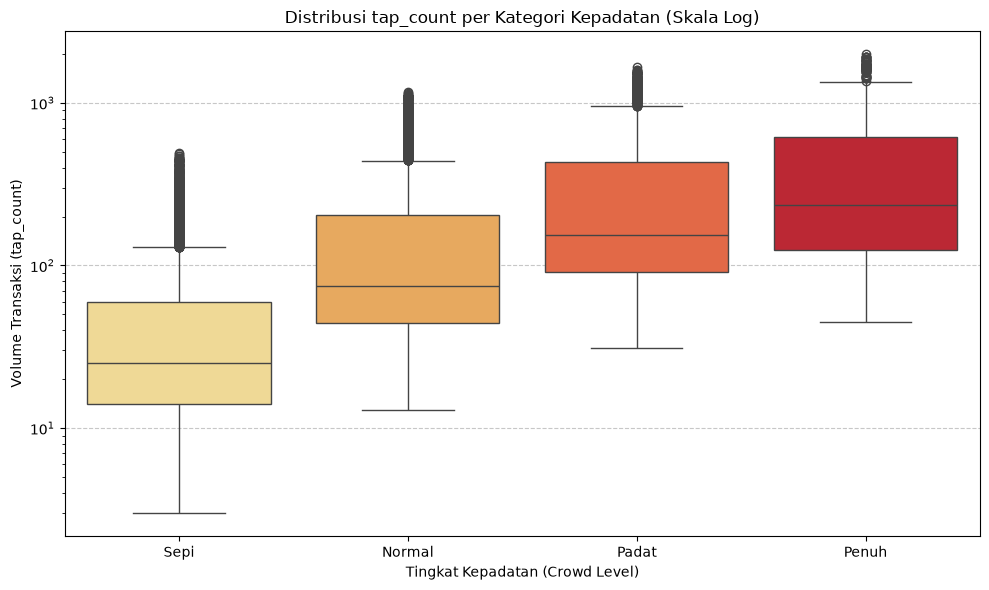

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_final, 
    x='crowd_level', 
    y='tap_count', 
    order=['Sepi', 'Normal', 'Padat', 'Penuh'],
    palette='YlOrRd'
)

plt.yscale('log') 
plt.title('Distribusi tap_count per Kategori Kepadatan (Skala Log)')
plt.xlabel('Tingkat Kepadatan (Crowd Level)')
plt.ylabel('Volume Transaksi (tap_count)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Insight:
- Separasi antar kelas monotonic dan jelas di skala log menandakan threshold labeling valid
- Overlap besar antara Padat dan Penuh di IQR, model mungkin kesulitan membedakan keduanya
- Outlier Sepi dan Normal ke atas: efek halte Besar di jam normal yang tap_count-nya absolut tinggi tapi load_pct tetap rendah

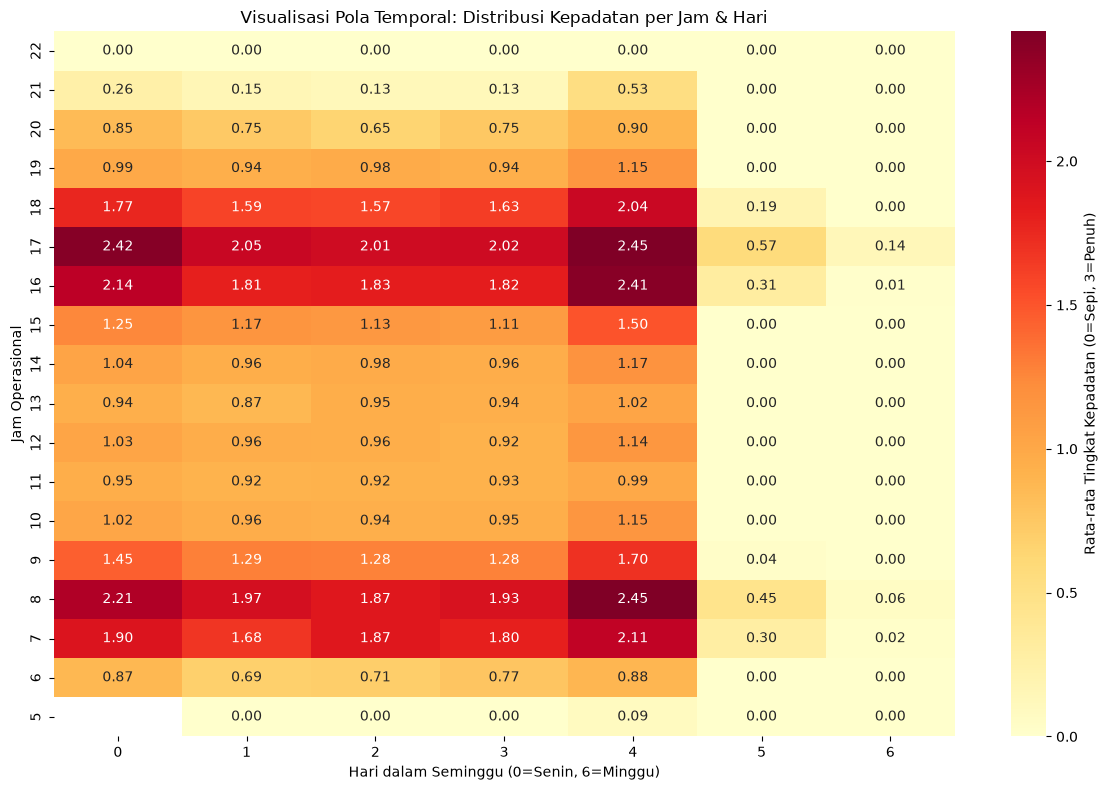

In [ ]:
pivot_temporal = df_final.pivot_table(
    values='crowd_level_encoded', 
    index='hour', 
    columns='day_of_week', 
    aggfunc='mean'
)

plt.figure(figsize=(12, 8))
sns.heatmap(
    pivot_temporal, 
    cmap='YlOrRd', 
    annot=True, 
    fmt=".2f",
    cbar_kws={'label': 'Rata-rata Tingkat Kepadatan (0=Sepi, 3=Penuh)'}
)

plt.title('Visualisasi Pola Temporal: Distribusi Kepadatan per Jam & Hari')
plt.xlabel('Hari dalam Seminggu (0=Senin, 6=Minggu)')
plt.ylabel('Jam Operasional')
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()

Insight:
- Pola peak terkonfirmasi, jam 7–8 dan 16–18 weekday konsisten di atas 1.5 (Padat–Penuh)
- Jumat (day=4) paling tinggi di hampir semua jam yang wajar karena sesuai DAY_MULTIPLIER 1.2
- Weekend (5–6) collapse ke 0.0–0.6 sebagai efek dari multiplier agresif, model tidak punya exposure kondisi padat di weekend sama sekali. Ini limitasi nyata untuk generalisasi, akibatnya model tidak pernah melihat data halte ramai di hari weekend saat training, jadi kalau di production ada halte yang ramai di weekend (konser, event besar, dll.), model tidak akan bisa memprediksinya dengan benar.